In [18]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.radnav_stacked_pc_tracking_tb import RadnavStackedPCTrackingTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker
from odometry.point_cloud_processing.dynamic_object_tracker import DynamicObjectTracker


In [19]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")
DATASET_PATH="D:\dataset"
MAP_DIRECTORY="D:\maps\maps"


#setup the datasets
# folder_name = "WILK_BASEMENT"
folder_name = ""
# file_name = "wilk_basement_0905_1"
file_name = "cpsl_dynamic_steady"
dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    # map_file="wilkinson.yaml"
    # map_file="wilk_basement.yaml"
    map_file="cpsl_full.yaml"
    
)

found 296 radar samples
found 296 lidar samples
found 296 camera samples
found 296 imu (orientation only) samples
found 296imu (full data) samples
found 296 vehicle velocity samples
loaded map from D:\maps\maps\cpsl_full.yaml
loaded map free space from D:\maps\maps\cpsl_full.yaml


In [20]:
# from dotenv import load_dotenv
# import os

# #loading enviroment variables
# load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
# MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

# #setup the datasets
# # folder_name = "WILK"
# folder_name = "WILK_BASEMENT"
# file_name = "WILK_Multipath_Test_5" #for point cloud comparison (frame 1340)
# # file_name = "WILK_Path_1_No_Dynamic"
# file_name = "wilk_basement_3" #wilk_basement_2 for point cloud processing (frame 780)

# dataset = radnavDS(
#     dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
#     radar_folder="radar_combined",
#     lidar_folder="lidar",
#     camera_folder="camera",
#     imu_orientation_folder="imu_data",
#     imu_full_folder="imu_data_full",
#     vehicle_vel_folder="vehicle_vel"
# )

# map_handler = MapHandler(
#     maps_folder=MAP_DIRECTORY,
#     map_file="wilk_basement_revB.yaml"#""wilk_basement_revB.yaml"
# )

In [21]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65 ->80
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=0 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

In [22]:
#initialize the point cloud stacker
pc_stacker = temporalPcStacker(
    num_frames_static_history = 4, # originally 4
    num_frames_dynamic_history = 0, # originally 0
    refresh_distance_m = 3, #originally 3
    refresh_rot_deg = 90, #originally 90
    refresh_time_s = 5, #originally 5
    grid_resolution_m = 5e-2, #originally 5e-2
    grid_max_distance_m = 20, #originally 20
    multi_path_clustering_eps = 0.5, #originally 0.5
    multi_path_clustering_min_samples = 15,  #originally 15
    multi_path_num_frames_history=4, # originally 4
    vel_filtering_enabled = True,
    vel_filtering_v_thresh = 0.05, # originally 0.05
    vel_filtering_min_static_rejection_radius = 0.25, #originally 0.25
    vel_filtering_dynamic_cluster_eps = 0.5, #originally 0.5
    vel_filtering_dynamic_cluster_min_samples = 15, #originally 15
    min_detection_radius_m=1.5, #originally 1.5
    max_detection_range_m=20, #originally 20
    gyro_bias=-0.0024 #originally -0.0024
)

#initialize the dynamic point cloud processor
dynamic_object_tracker = DynamicObjectTracker(
    vel_filtering_v_thresh=0.05,
    dbscan_eps=0.3,
    dbscan_min_samples=5
)

loaded map with 6832 points
loaded map with 6832 points
gt icp estimated heading:2.8197327766160143 deg, pose:[0.02419837 0.01797778]


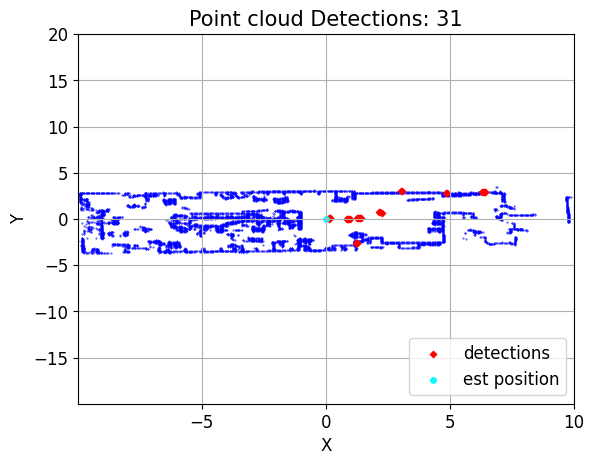

In [23]:
test_bench = RadnavStackedPCTrackingTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    pc_stacker=pc_stacker,
    dynamic_object_tracker=dynamic_object_tracker
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024 #originally -0.0024
)

#initialize the point cloud stacker
test_bench.init_pc_stacker(
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

found temp dir: D:\movie_temp
clearing temp directory D:\movie_temp


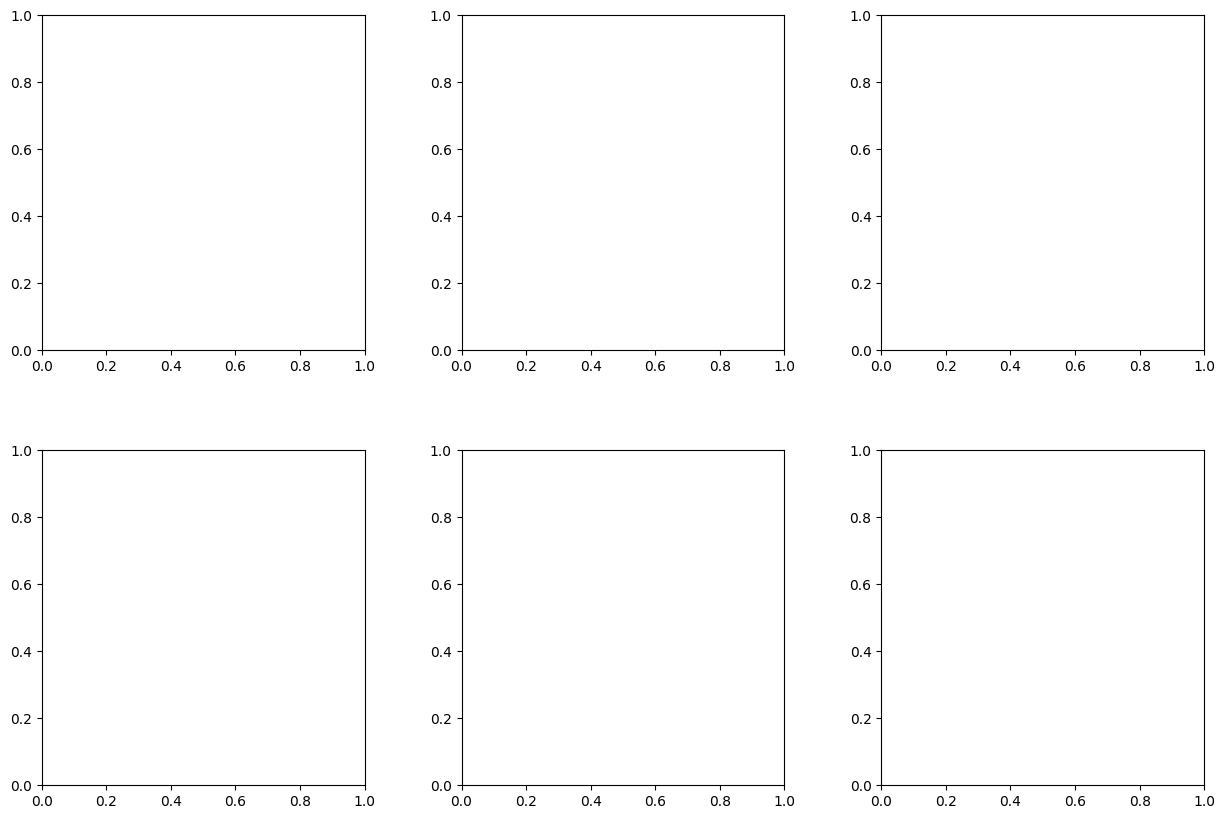

In [24]:
#loading directory from .env file
# MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")
MOVIE_TEMP_DIRECTORY = "D:\movie_temp"

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [25]:


end_idx = dataset.num_frames # for full dataset, use "dataset.num_frames" #point cloud sample: frame 1340 on Wilk_Multipath_test_5 (now 960)
save_name = file_name + "radar_combined_frames_steady"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False, #if not desired set to False
    # movie_generator= movie_generator) #if not desired, set to None
    movie_generator= None) #if not desired, set to None

#run to around 1:07 mark for looking at the point cloud

100%|██████████| 296/296 [00:01<00:00, 277.63it/s]


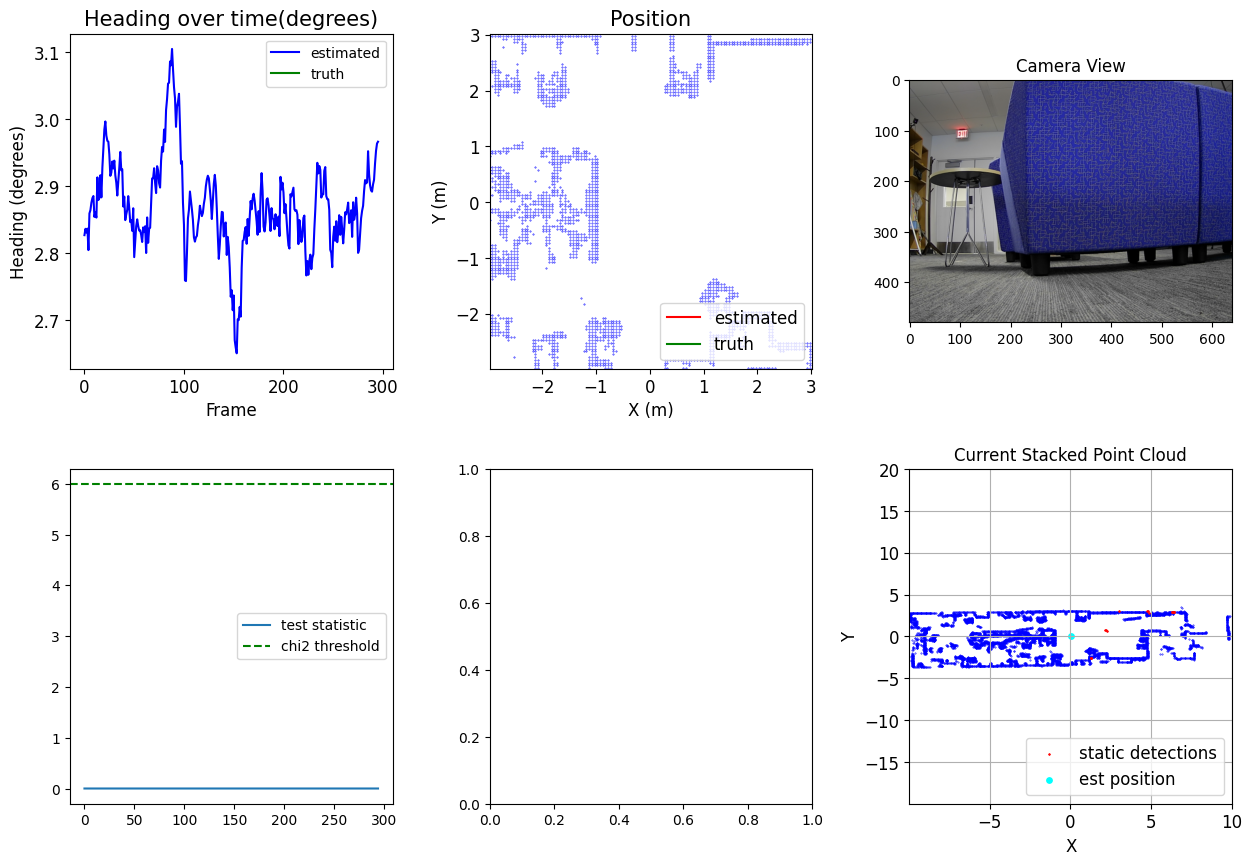

In [26]:
test_bench.plot_compilation(
    show=True,
    idx=end_idx -1
)

In [27]:
#evaluating processing times
update_periods = np.array(test_bench.history_update_periods)
processing_times = np.array(test_bench.history_update_actitve_compute_times)

percent_processing_times = 100 * np.divide(processing_times, update_periods)
# np.save("processing_times/radnav.npy",percent_processing_times)

In [28]:
#save trajectories
# np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
# np.save("Trajectories/radnav.npy",test_bench.history_position_m)

In [29]:
save_name = 'radar_combined_frames_steady'
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

0it [00:00, ?it/s]


The following points belongs to a single frame. A K-distance plot is created to identify appropriate parameters for the cluster.

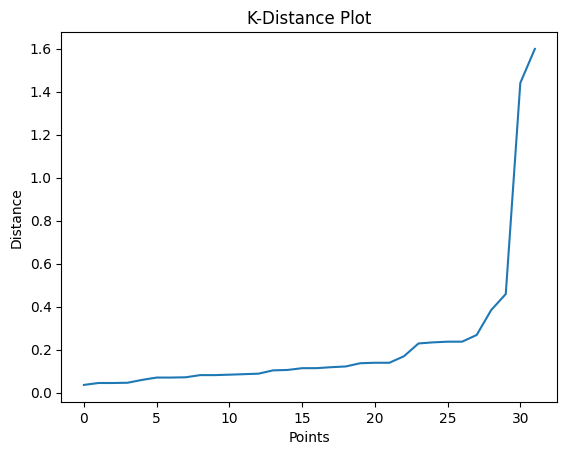

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Example points
points = np.array([
    [13.6776876, -2.76749454], [13.54805174, -3.09493996], [13.54573125, -3.12980137],
    [13.54945349, -3.16594041], [13.54980561, -3.20010433], [12.78214064, -4.11982109],
    [12.72758333, -4.12406814], [12.70643713, -4.15242407], [12.68529092, -4.18078],
    [12.69924088, -4.23423237], [12.67977974, -4.26357586], [11.15069364, -5.79878677],
    [12.26774717, -4.52240432], [11.12716488, -5.82348252], [11.00543871, -6.36337827],
    [10.88028164, -6.31040212], [12.58255768, -4.09340519], [12.55902892, -4.11810094],
    [12.57001619, -4.17660849], [12.50999627, -4.17086256], [11.19804122, -5.74503759],
    [10.9631463, -6.42009013], [10.83560668, -6.36345381], [12.56084483, -4.26178691],
    [11.32838432, -5.94367482], [13.52486836, -3.08814441], [13.5104624, -3.12045057],
    [13.44027007, -3.07025768], [13.40471115, -3.06526456], [10.75471713, -6.25039569],
    [12.37510111, -7.17062255], [12.43743606, -6.52347667]
])

# Compute nearest neighbors
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(points)
distances, indices = neighbors_fit.kneighbors(points)

# Sort distances for plotting
distances = np.sort(distances[:, 3], axis=0)  # Use the 4th neighbor
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()


In [31]:
test_bench.dynamic_object_tracker.history_clustered_dynamic_clusters_nums

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 2,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 2,
 0,
 1,
 2,
 2,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [32]:
test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids

[{},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {},
 {0: array([ 2.55647849, -0.22652741])},
 {},
 {0: array([ 0.55976964, -0.58224458])},
 {0: array([ 0.6619728 , -0.55067447])},
 {},
 {0: array([ 0.79611369, -0.03789125])},
 {0: array([0.74368219, 0.01795708]), 1: array([ 0.53296028, -0.34961333])},
 {},
 {0: array([0.6376104, 0.1131826])},
 {0: array([0.69011197, 0.31677687])},
 {0: array([0.51110011, 0.49024056])},
 {},
 {0: array([0.75107719, 0.31581784])},
 {0: array([0.66901833, 0.53070934])},
 {0: array([0.60299039, 0.8340674 ])},
 {},
 {},
 {0: array([0.39956651, 0.86493282])},
 {0: array([0.43796502,

In [55]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# Determine the number of rows and columns for the subplots
r = int(150 / 2) + 1  # Adjusted to handle a maximum of 100 frames
c = 2

# Create subplots with specified figure size
fig, axs = plt.subplots(r, c, figsize=(20, 5 * r))

# Ensure axs is a 2D array even if rows or columns are 1
if r == 1 or c == 1:
    axs = axs.reshape(r, c)

# Flatten axs to handle indexing easily
axs = axs.flatten()

# Initialize subplot index
subplot_idx = 0

# Set marker size for the plot
test_bench.plotter_localization.marker_size = 0.5

# Counter for valid (non-empty) frames
valid_frame_count = 0

# Iterate over the history of dynamic objects
for idx in tqdm(range(len(test_bench.dynamic_object_tracker.history_dynamic_objects))):
    # Stop after displaying 100 non-empty frames
    if valid_frame_count >= 200:
        break

    # Get the current frame's dynamic objects
    current_points = test_bench.dynamic_object_tracker.history_dynamic_objects[idx]

    # Skip empty frames
    if current_points.shape[0] < 1:
        print(f"Skipping empty frame {idx}")
        continue

    # Plot the detections on the map
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=current_points,
        ax=axs[subplot_idx],  # Use the flattened subplot index
        show=False,
        # frame_number=idx,
    )

    # Set the limits for the subplot
    axs[subplot_idx].set_ylim(-5, 5)
    axs[subplot_idx].set_xlim(-10, 10)
    axs[subplot_idx].set_title(f"Point Cloud Detection {current_points.shape[0]} | Frames {idx}")  # Add title for each frame

    # Increment the subplot index and valid frame counter
    subplot_idx += 1
    valid_frame_count += 1

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()


  0%|          | 0/296 [00:00<?, ?it/s]

Skipping empty frame 0
Skipping empty frame 1
Skipping empty frame 2
Skipping empty frame 3
Skipping empty frame 4
Skipping empty frame 5
Skipping empty frame 6
Skipping empty frame 7
Skipping empty frame 8
Skipping empty frame 9
Skipping empty frame 10
Skipping empty frame 11
Skipping empty frame 12
Skipping empty frame 13
Skipping empty frame 14
Skipping empty frame 15
Skipping empty frame 16
Skipping empty frame 17
Skipping empty frame 18
Skipping empty frame 19
Skipping empty frame 20
Skipping empty frame 21
Skipping empty frame 22
Skipping empty frame 23
Skipping empty frame 24
Skipping empty frame 25
Skipping empty frame 26
Skipping empty frame 27
Skipping empty frame 28
Skipping empty frame 29
Skipping empty frame 30
Skipping empty frame 31
Skipping empty frame 32
Skipping empty frame 33
Skipping empty frame 34
Skipping empty frame 35
Skipping empty frame 36
Skipping empty frame 37
Skipping empty frame 38
Skipping empty frame 39
Skipping empty frame 40
Skipping empty frame 41
Sk

 53%|█████▎    | 156/296 [00:00<00:00, 237.48it/s]

Skipping empty frame 107
Skipping empty frame 108
Skipping empty frame 109
Skipping empty frame 110
Skipping empty frame 111
Skipping empty frame 112
Skipping empty frame 113
Skipping empty frame 114
Skipping empty frame 115
Skipping empty frame 116
Skipping empty frame 117
Skipping empty frame 118
Skipping empty frame 119
Skipping empty frame 120
Skipping empty frame 121
Skipping empty frame 122
Skipping empty frame 123
Skipping empty frame 124
Skipping empty frame 125
Skipping empty frame 126
Skipping empty frame 127
Skipping empty frame 128
Skipping empty frame 129
Skipping empty frame 130
Skipping empty frame 131
Skipping empty frame 132
Skipping empty frame 133
Skipping empty frame 136
Skipping empty frame 138
Skipping empty frame 165
Skipping empty frame 190


100%|██████████| 296/296 [00:00<00:00, 305.52it/s]


Skipping empty frame 225
Skipping empty frame 227
Skipping empty frame 228
Skipping empty frame 229
Skipping empty frame 230
Skipping empty frame 231
Skipping empty frame 232
Skipping empty frame 233
Skipping empty frame 234
Skipping empty frame 235
Skipping empty frame 236
Skipping empty frame 237
Skipping empty frame 238
Skipping empty frame 239
Skipping empty frame 240
Skipping empty frame 241
Skipping empty frame 242
Skipping empty frame 243
Skipping empty frame 244
Skipping empty frame 245
Skipping empty frame 246
Skipping empty frame 247
Skipping empty frame 248
Skipping empty frame 249
Skipping empty frame 250
Skipping empty frame 251
Skipping empty frame 252
Skipping empty frame 253
Skipping empty frame 254
Skipping empty frame 255
Skipping empty frame 256
Skipping empty frame 257
Skipping empty frame 258
Skipping empty frame 259
Skipping empty frame 260
Skipping empty frame 261
Skipping empty frame 262
Skipping empty frame 263
Skipping empty frame 264
Skipping empty frame 265


In [35]:
current_centroids = test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids[100]
centroid_points = np.array(list(current_centroids.values()))
print(centroid_points)

[[0.66901833 0.53070934]]


In [36]:
frames_data = []

for frame_centroids in test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids:
    frames_data.append(np.array(list(frame_centroids.values())))


In [37]:
frames_data


[array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 array([], dtype=float64),
 

In [38]:
len(frames_data)

296

In [39]:
import pickle

# Save frames_data as a pickle file
with open('frames_data.pkl', 'wb') as f:
    pickle.dump(frames_data, f)

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from avstack.datastructs import DataContainer
from avstack.geometry import GlobalOrigin2D
from avstack.modules.perception.detections import CentroidDetection
from avstack.modules.tracking import BasicXyTracker

# Initialize the tracker
P0 = np.diag([1, 1, 5, 5]) ** 2
tracker = BasicXyTracker(
    threshold_confirmed=10,   # Minimum hits to confirm a track
    threshold_coast=5.0,     # Maximum frames without updates before deletion
    v_max=10.0,              # Maximum allowed velocity
    assign_metric="center_dist",
    assign_radius=1.0,
    P0=P0,
)


No torch found.
MIDAS module not found.
A `BasicClusterer` instance is built from registry, and its implementation can be found in avstack.modules.clustering.clusterers


In [41]:
imu_data = dataset.get_imu_full_data(idx=0)
current_imu_data = dataset.get_imu_full_data(idx=5)
print(current_imu_data[-1][0] - imu_data[-1][0])


0.5297088623046875


In [56]:
# dt = 0.1  # Time step between frames (in seconds)
imu_data = dataset.get_imu_full_data(idx=0)
initial_timestamp = imu_data[-1][0]

final_tracks = {}

for i_frame, centroids in enumerate(frames_data):
    current_imu_data = dataset.get_imu_full_data(idx=i_frame)
    current_time_stamp = current_imu_data[-1][0]
    timestamp = current_time_stamp - initial_timestamp

    # Create a DataContainer to hold detections for the current frame
    msmts = DataContainer(
        frame=i_frame,
        timestamp=timestamp,
        source_identifier="sensor",
        data=[],
    )

    # Add centroids as detections
    for centroid in centroids:
        msmts.append(
            CentroidDetection(
                data=centroid,                # Position data [x, y]
                noise=np.array([0.5, 0.5]),   # Measurement noise (adjust as needed)
                source_identifier="sensor",
                reference=GlobalOrigin2D,     # Coordinate reference
            )
        )

    # Pass detections to the tracker
    tracks = tracker(
        detections=msmts,
        platform=GlobalOrigin2D,
        check_reference=False,  # Skip reference consistency check
    )
    
    for track in tracks:
        if track.ID not in final_tracks:
            final_tracks[track.ID] = []  

        final_tracks[track.ID].append(track.position)
    # # Print tracking results for the current frame
    # print(f"Frame {i_frame}:")
    # for track in tracks:
    #     print(f"Track ID: {track.id}, Position: {track.positions[-1]}")
    
print(len(final_tracks))


4


In [57]:
final_tracks

{9: [<class 'avstack.geometry.datastructs.Position'> - [ 0.63418009 -0.55925952], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [ 0.6505631  -0.55419888], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [ 0.76789532 -0.14962116], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.77191547 0.00458346], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.8130843  0.16479777], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.70310065 0.17708655], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.6989544  0.30304424], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.61547722 0.44734175], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.60594582 0.55852488], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.67557093 0.49269875], GlobalOrigin,
  <class 'avstack.geometry.datastructs.Position'> - [0.67308444 0.56245024], Glob

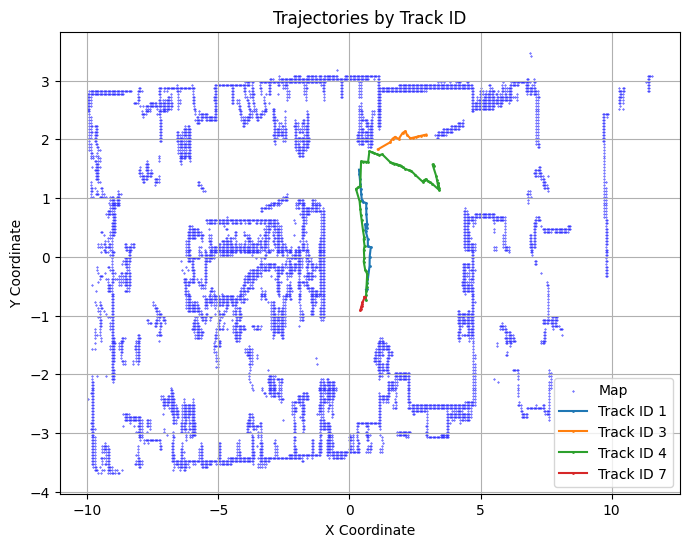

In [44]:
# Initialize a dictionary to store valid tracks with extracted coordinates
valid_tracks = {}

# Extract `x, y` coordinates from positions and store them by track ID
for track_id, positions in final_tracks.items():
    if positions:  # Check if positions list is not empty
        try:
            # Convert Position objects to NumPy array of shape (N, 2)
            coords = np.array([[pos[0], pos[1]] for pos in positions])
            valid_tracks[track_id] = coords
        except AttributeError as e:
            print(f"Error processing Track ID {track_id}: {e}")

# Prepare a plot
plt.figure(figsize=(8, 6))

# Plot the map
map_points = map_handler.map_points
plt.scatter(
    map_points[:, 0],
    map_points[:, 1],
    label="Map",
    marker=".",
    s=0.5,
    color="blue"
)

# Iterate over valid tracks to plot each ID's trajectory
for track_id, points in valid_tracks.items():
    # Convert points to a numpy array for slicing
    points = np.array(points)  # Ensure points is a NumPy array
    
    # Plot trajectory for this ID
    plt.plot(
        points[:, 0],  # X coordinates
        points[:, 1],  # Y coordinates
        label=f'Track ID {track_id}',  # Label for the legend
        marker='o',
        markersize=1
    )

# Add labels and legend
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Trajectories by Track ID')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# # Filter out empty arrays
# valid_data = [d for d in final_tracks if d.size > 0]

# # Prepare a plot
# plt.figure(figsize=(8, 6))

# #plot the map
# map_points = map_handler.map_points
# plt.scatter(
#     map_points[:,0],
#     map_points[:,1],
#     label="map",
#     marker=".",
#     s=0.5,
#     color="blue")

# # Iterate over columns (indices) of valid arrays
# for i in range(valid_data[0].shape[1]):  # Assuming at least one valid array with consistent shapes
#     x_coords = []
#     y_coords = []
#     for d in valid_data:
#         if d.shape[1] > i:  # Ensure the index exists
#             x_coords.append(d[0, i])
#             y_coords.append(d[1, i])
    
#     # Plot trajectory
#     plt.plot(x_coords, y_coords, label=f'Trajectory {i + 1}', marker='o', markersize=1)

# # Add labels and legend
# plt.xlabel('X Coordinate')
# plt.ylabel('Y Coordinate')
# plt.title('Trajectories')
# plt.legend()
# plt.grid()
# plt.show()

AttributeError: 'int' object has no attribute 'size'

In [46]:
for i in final_tracks:
    print(i)
    print('\n')

1


3


4


7




In [47]:
from tqdm import tqdm
import matplotlib.pyplot as plt

# Determine the number of rows and columns for the subplots
r = int(200 / 2) + 1  # Adjusted to handle a maximum of 200 frames
c = 2

# Create subplots with specified figure size
fig, axs = plt.subplots(r, c, figsize=(20, 5 * r))

# Ensure axs is a 2D array even if rows or columns are 1
if r == 1 or c == 1:
    axs = axs.reshape(r, c)

# Flatten axs to handle indexing easily
axs = axs.flatten()

# Initialize subplot index
subplot_idx = 0

# Counter for valid (non-empty) frames
valid_frame_count = 0

# Iterate over the history of clustered centroids
for idx in tqdm(range(len(test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids))):
    # Stop after displaying 200 non-empty frames
    if valid_frame_count >= 200:
        break

    # Get the current frame's clustered centroids
    current_centroids = test_bench.dynamic_object_tracker.history_clustered_dynamic_centroids[idx]

    # Skip empty frames
    if len(current_centroids) == 0:
        print(f"Skipping empty frame {idx}")
        continue

    # Convert centroids dictionary to array for plotting
    centroid_points = np.array(list(current_centroids.values()))

    # Plot the centroids on the map using plot_detections_on_map
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=centroid_points,
        ax=axs[subplot_idx],  # Use the flattened subplot index
        show=False,
        frame_number=idx,
    )

    test_bench.plotter_localization.marker_size = 100

    # Set the limits for the subplot
    axs[subplot_idx].set_ylim(-20, 10)
    axs[subplot_idx].set_xlim(-20, 40)
    axs[subplot_idx].set_title(f"Frame {idx}")  # Add title for each frame

    # Increment the subplot index and valid frame counter
    subplot_idx += 1
    valid_frame_count += 1

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()


 29%|██▉       | 87/296 [00:00<?, ?it/s]

Skipping empty frame 0
Skipping empty frame 1
Skipping empty frame 2
Skipping empty frame 3
Skipping empty frame 4
Skipping empty frame 5
Skipping empty frame 6
Skipping empty frame 7
Skipping empty frame 8
Skipping empty frame 9
Skipping empty frame 10
Skipping empty frame 11
Skipping empty frame 12
Skipping empty frame 13
Skipping empty frame 14
Skipping empty frame 15
Skipping empty frame 16
Skipping empty frame 17
Skipping empty frame 18
Skipping empty frame 19
Skipping empty frame 20
Skipping empty frame 21
Skipping empty frame 22
Skipping empty frame 23
Skipping empty frame 24
Skipping empty frame 25
Skipping empty frame 26
Skipping empty frame 27
Skipping empty frame 28
Skipping empty frame 29
Skipping empty frame 30
Skipping empty frame 31
Skipping empty frame 32
Skipping empty frame 33
Skipping empty frame 34
Skipping empty frame 35
Skipping empty frame 36
Skipping empty frame 37
Skipping empty frame 38
Skipping empty frame 39
Skipping empty frame 40
Skipping empty frame 41
Sk

TypeError: PlotterLocalization.plot_detections_on_map() got an unexpected keyword argument 'frame_number'

In [ ]:
save_name = "first_300_frames_larger_than_30_points"
fig.savefig("./{}.png".format(save_name))


In [ ]:
len(test_bench.dynamic_object_tracker.history_dynamic_objects[3])

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


plot_name = "dynamic_points_frames_1"

# calculate the number of rows and columns
# total_plots = len(test_bench.history_dynamic_pc_point_clouds)
total_plots = 1
c = 2  
r = int(np.ceil(total_plots / c))  # calculate rows

# fig, axs = plt.subplots(r, c, figsize=(20, 4 * r))  # figsize=(width, height)
# axs = axs.flatten()  # flatten the axs to 1D array

idx = 176

test_bench.plotter_localization.plot_detections_on_map(
    current_points=np.array(test_bench.dynamic_object_tracker.history_dynamic_objects[idx]),
    # ax=axs[idx],
    show=True
)


In [ ]:
from tqdm import tqdm

r = int(len(test_bench.dynamic_object_tracker.current_dynamic_detections)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.dynamic_object_tracker.current_dynamic_detections))):
    if len(test_bench.dynamic_object_tracker.current_dynamic_detections[idx]) < 0:
        continue
    print(len(test_bench.dynamic_object_tracker.current_dynamic_detections[idx]))
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.dynamic_object_tracker.current_dynamic_detections[idx],
        # ax=axs[cc,rc],
        show=False,
        frame_number=idx,
    )
    test_bench.plotter_localization.marker_size = 10
    # axs[cc,rc].set_ylim(-20,10)
    # axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

In [ ]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=file_name,
    export_to_csv=False
)

In [ ]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

In [ ]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

# fig.savefig("Images/position_history/{}.png".format(save_name))

In [ ]:
print(test_bench.filter.x[0:3])
print(test_bench.gt_localizer.current_pose_m)
print(test_bench.point_cloud_stacker.integrator.x[0:3])
print(test_bench.point_cloud_stacker.initial_pose_m)
print(test_bench.point_cloud_stacker.current_pose_m)
print(np.linalg.norm(test_bench.gt_localizer.current_pose_m - test_bench.filter.x[0:2]))

In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

In [ ]:
#visualizing the point cloud - for point cloud comparison
fig, axs = plt.subplots(figsize=(3,1.5))

combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
dynamic_combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_dynamic()

test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[-1],
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=axs,
    show=False
) 
axs.set_title("RadNav",
                fontsize=test_bench.plotter_localization.font_size_legend)
axs.set_xlim(
    test_bench.filter.x[0] - 10,
    test_bench.filter.x[0] + 3)
axs.set_xlabel("X (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
axs.set_ylim(
    test_bench.filter.x[1] - 3,
    test_bench.filter.x[1] + 9)
axs.set_ylabel("Y (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
handles,labels = axs.get_legend_handles_labels()
print(labels)
axs.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)

plt.show()

In [ ]:
#visualizing the point cloud - for processing visualization
fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(7,5))
plt.subplots_adjust(hspace=0.3)
#top left - single radar point cloud
ax=axs[0,0]
pc = dataset.get_radar_detections(idx=end_idx)[:,0:2]
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
)
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Radar Detections",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - stacked point cloud
ax=axs[0,1]
combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
dynamic_combined_pc = test_bench.point_cloud_stacker.get_current_stacked_pc_dynamic()
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=np.append(combined_pc,dynamic_combined_pc,axis=0),
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Stacked Point Cloud",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom left - velocities filtered
ax=axs[1,0]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=combined_pc,
    dynamic_points=dynamic_combined_pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[3:4], labels[3:4], loc="upper right",fontsize=10)
ax.set_title("Dynamic Object Detection",
                fontsize=test_bench.plotter_localization.font_size_legend)

#bottom right - final point cloud
test_bench.point_cloud_stacker.refresh()
pc = test_bench.point_cloud_stacker.get_latest_pc()
ax=axs[1,1]
test_bench.plotter_localization.marker_size = 0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=ax,
    show=False
) 
handles,labels = ax.get_legend_handles_labels()
ax.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)
ax.set_title("Multipath Removal",
                fontsize=test_bench.plotter_localization.font_size_legend)

for r in range(2):
    for c in range(2):
        axs[r,c].set_xlim(
            test_bench.filter.x[0] - 10,
            test_bench.filter.x[0] + 10)
        axs[r,c].set_xlabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)
        axs[r,c].set_ylim(
            test_bench.filter.x[1] - 1,
            test_bench.filter.x[1] + 13)
        axs[r,c].set_ylabel("",fontsize=test_bench.plotter_localization.font_size_axis_labels)

plt.show()

In [ ]:
#visualizing the point cloud
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2]
)

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)


In [ ]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

In [ ]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

## Debugging (testing ray tracing)

In [ ]:
#timing analysis
pc_grid_static_orig = test_bench.point_cloud_stacker.pc_grid_static.copy()
pc_grid_dynamic_orig = test_bench.point_cloud_stacker.pc_grid_dynamic.copy()

for i in tqdm(range(500)):

    test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
    test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

    test_bench.point_cloud_stacker.refresh()

#reset the point cloud stacker:
test_bench.point_cloud_stacker.pc_grid_static = pc_grid_static_orig.copy()
test_bench.point_cloud_stacker.pc_grid_dynamic = pc_grid_dynamic_orig.copy()

In [ ]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#recenter the point cloud grids
pc_grids_static = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_static,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)

pc_grid_dynamic = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_dynamic,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)


current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grids_static[0:1])
dynamic_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid_dynamic)

print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=current_points,
    dynamic_points = dynamic_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = \
    test_bench.point_cloud_stacker.vel_filtering.remove_dynamic_clusters_from_static_detections_knn(
        current_points,
        dynamic_points
    )

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#perform current multi-path
multipath_num_frames_history = 2

#update the static point grid
pc_grids_static[0] = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static[0:multipath_num_frames_history+1])

labels = test_bench.point_cloud_stacker.multi_path._cluster_points(current_points)

fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=current_points,
    labels=labels,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)


ax.set_ylim(-10,10)
plt.show()

In [ ]:
#remove velocity detections
current_points = test_bench.point_cloud_stacker.multi_path.remove_multipath(
    pc_cartesian=current_points
)

grid = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
pc_grids_static[0] = np.logical_and(grid,pc_grids_static[0])

current_points = test_bench.point_cloud_stacker._get_points_from_pc_grid(pc_grids_static[0])

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    valid_stacked_pc_cart = test_bench.point_cloud_stacker.multi_path.remove_multipath(current_points)

### Debugging ICP

In [ ]:
#get the point cloud (from the previous step)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static
)
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.filter.x[2],
    pose_m= test_bench.filter.x[0:2],
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#configure icp for only a single update
test_bench.localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.localizer.update_odometry(
        points=current_points,
        estimated_heading_rad=test_bench.filter.x[2],
        estimated_pose_m=test_bench.filter.x[0:2]
    )

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=100

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False,
)

ax.set_ylim(-10,10)
plt.show()

### Evaluating processing time for lidar localization

In [ ]:
pc = dataset.get_lidar_point_cloud(idx=end_idx-1)

#configure icp for only a single update
test_bench.gt_localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.gt_localizer.update_odometry(
        points=pc[:,0:2],
        estimated_heading_rad=test_bench.filter_gt.x[2],
        estimated_pose_m=test_bench.filter_gt.x[0:2]
    )
print(pc.shape[0])